In [11]:
import torch
from torch import nn
from torch.utils.data import Dataset
from torchvision import transforms

import pytorch_lightning as pl
from torch.utils.data import DataLoader, random_split

import torch.optim as optim

import pytorch_lightning as pl
from torchvision.models import resnet18

import cv2
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import os
import sys
import time

sys.path.append(str(Path("../src").resolve()))
from spectogram_datamodule import SpektogramDataModule
from custom_transform import ShuffleChannels

FOLDER_PATH = Path(r"../spectogram_wieliczka")
TEST_FOLDER_PATH = Path(r"../spectogram_ziemowit")
NUM_CLASSES = 2

In [ ]:
spectrogram_transforms = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Resize((224, 224)), 
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
    ShuffleChannels(0.5)
])

dm_wieliczka = SpektogramDataModule(FOLDER_PATH, spectrogram_transforms)
dm_wieliczka.setup()

dm_ziemowit = SpektogramDataModule(TEST_FOLDER_PATH, spectrogram_transforms, test_split=1, num_workers=0)
dm_ziemowit.setup()


plt.imshow(next(iter(dm_wieliczka.train_dataloader()))[0][3].numpy().transpose(1, 2, 0))

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.
ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.
ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Error in callback <function install_repl_displayhook.<locals>.post_execute at 0x7f1b542378> (for post_execute):


KeyboardInterrupt: 

ValueError: Floating point image RGB values must be in the 0..1 range.

In [12]:
class LitResNet(pl.LightningModule):
	def __init__(self, num_classes=10, lr=1e-3):
		super().__init__()
		self.save_hyperparameters()
		self.lr = lr

		self.model = resnet18(pretrained=False, num_classes=num_classes)
		self.criterion = nn.CrossEntropyLoss()


		self.train_loss_history = []
		self.train_acc_history = []

		self.val_loss_history = []
		self.val_acc_history = []

		self.test_loss_history = []
		self.test_acc_history = []

	def forward(self, x):
		# return self.model(x)
		x = self.model.conv1(x)
		x = self.model.bn1(x)
		x = self.model.relu(x)
		x = self.model.maxpool(x)
		x = self.model.layer1(x)
		x = self.model.layer2(x)
		x = self.model.layer3(x)
		x = self.model.layer4(x)
		x = self.model.avgpool(x)
		x = torch.flatten(x, 1)
		x = self.model.fc(x)

		return x



	def training_step(self, batch, batch_idx):
		x, y = batch
		y_hat = self(x)
		loss = self.criterion(y_hat, y)
		acc = (y_hat.argmax(dim=1) == y).float().mean()

		self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
		self.log("train_acc", acc, on_step=True, on_epoch=True, prog_bar=True)

		self.train_loss_history.append(loss.detach().cpu())
		self.train_acc_history.append(acc.detach().cpu())

		return loss


	def validation_step(self, batch, batch_idx):
		x, y = batch
		y_hat = self(x)
		loss = self.criterion(y_hat, y)
		acc = (y_hat.argmax(dim=1) == y).float().mean()
		self.val_loss_history.append(loss.detach().cpu())
		self.val_acc_history.append(acc.detach().cpu())
		self.log("val_loss", loss, on_epoch=True, prog_bar=True)
		self.log("val_acc", acc, on_epoch=True, prog_bar=True)
		return loss

	def test_step(self, batch, batch_idx):
		x, y = batch
		start_time = time.time()  
		
		y_hat = self(x)
		loss = self.criterion(y_hat, y)
		acc = (y_hat.argmax(dim=1) == y).float().mean()
		
		end_time = time.time()  
		
		batch_time = end_time - start_time  
		batch_size = x.size(0)
		fps = batch_size / batch_time  
		
		self.test_loss_history.append(loss.detach().cpu())
		self.test_acc_history.append(acc.detach().cpu())

		self.log("test_loss", loss, on_epoch=True, prog_bar=True)
		self.log("test_acc", acc, on_epoch=True, prog_bar=True)
		self.log("test_fps", fps, on_epoch=True, prog_bar=True)  
		
		return loss

	def configure_optimizers(self):
		return optim.SGD(self.parameters(), lr=self.lr, momentum=0.9)

In [13]:
model = LitResNet(num_classes=NUM_CLASSES, lr=1e-3)

trainer = pl.Trainer(
    precision=16,
    accelerator='gpu',
    devices=1,
    max_epochs=50
)

# trainer.fit(model, dm_wieliczka)

Using 16bit native Automatic Mixed Precision (AMP)
GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs


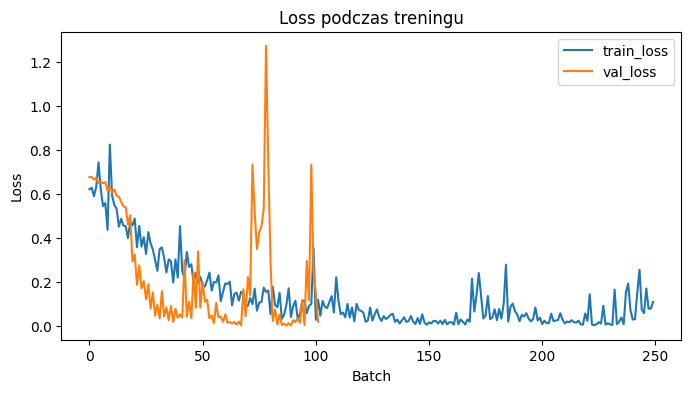

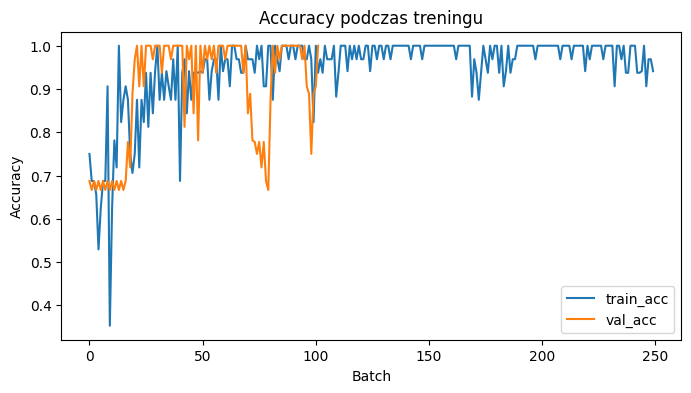

In [18]:
import matplotlib.pyplot as plt

# Loss
plt.figure(figsize=(8,4))
plt.plot(model.train_loss_history, label="train_loss")
plt.plot(model.val_loss_history, label="val_loss")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.title("Loss podczas treningu")
plt.legend()
plt.show()

# Accuracy
plt.figure(figsize=(8,4))
plt.plot(model.train_acc_history, label="train_acc")
plt.plot(model.val_acc_history, label="val_acc")
plt.xlabel("Batch")
plt.ylabel("Accuracy")
plt.title("Accuracy podczas treningu")
plt.legend()
plt.show()


In [19]:
trainer.test(model, dm_ziemowit)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 20.90it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.32258063554763794
        test_fps             1497.12060546875
        test_loss            5.543695449829102
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 5.543695449829102,
  'test_acc': 0.32258063554763794,
  'test_fps': 1497.12060546875}]

In [7]:
# sample = next(iter(dm_ziemowit.test_dataloader()))[0][0]
# sample = sample.unsqueeze(0).cuda().half() 

# model.eval().cuda()

# trt_model = torch_tensorrt.compile(
#     model,
#     inputs=[torch_tensorrt.Input(sample.shape, dtype=torch.half)],
#     enabled_precisions={torch.half},
#     workspace_size=1 << 20
# )

# with torch.no_grad():
#     out = trt_model(sample)
# print(out.shape)

In [8]:
next(iter(dm_ziemowit.test_dataloader()))[0][0].shape

torch.Size([3, 224, 224])

In [15]:
lit_model = LitResNet(num_classes=NUM_CLASSES)

state_dict = torch.load("models/resnet18.pth", map_location="cpu")

# 🔥 KLUCZOWA LINIA
lit_model.model.load_state_dict(state_dict)

model = lit_model.model
model.eval()

sample = torch.randn(1, 3, 224, 224)

with torch.no_grad():
    torch.onnx.export(
        model,
        sample,
        "models/resnet18.onnx",
        input_names=["input"],
        output_names=["output"],
        opset_version=11,
        dynamic_axes={
            "input": {0: "batch_size"},
            "output": {0: "batch_size"}
        },
        do_constant_folding=True,
    )

In [24]:
import onnxruntime as ort

session = ort.InferenceSession(
    "models/resnet18.onnx",
    providers=["CUDAExecutionProvider"]
)

print(session.get_providers())


['CUDAExecutionProvider', 'CPUExecutionProvider']


In [29]:
outputs = session.run(
    None,                 # None = wszystkie outputy
    {"input": sample.cpu().numpy()}   # nazwa inputa z exportu
)

outputs[0].argmax(axis=1)

array([1])